# Laser Interferometer Space Antenna (LISA)
\
Alex Correia \
Syracuse University \
Spring 2026

In [1]:
import numpy as np
import sympy

from ipywidgets import *
import matplotlib as mpl
import matplotlib.pyplot as plt
from pycbc import psd
from pycbc.waveform import get_fd_waveform
from pycbc.conversions import mass1_from_mchirp_q, mass2_from_mchirp_q

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

/Users/alcorrei/miniforge3/envs/lasers/lib/python3.13/importlib/__init__.py:88: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


## Overview: Why space-based detectors?

Over the past 10 years, the LIGO-Virgo-KAGRA (LVK) Collaboration confirmed the detection of dozens of gravitational wave (GW) signals. With this network of ground-based detectors, we can "see" when stellar-mass objects coalesce and merge, which according to general relativity (GR) emits a short, powerful burst of energy via GWs. We can use these signals to perform studies of the populations and environments of astrophysical objects, examine the links between electromagnetic and GW emissions via multimessenger astronomy, and test GR to the most stringent limits currently available.

All of the GW signals discovered so far by the LVK originate from the coalescence and merger of compact objects in the range of a few to hundreds of solar masses. However, this mass range does not represent the full population of astrophysical objects; the documented existence of type Ia supernovae, the supermassive BHs at the centers of most galaxies, and our own Sun indicate as much. The design of the LVK detectors makes it such that we can only detect mergers that occur in a small range of frequencies - typically between 10 and 1000 Hz. So, if we want to probe the full range of astrophysical bodies, we require detectors that surmount the challenges that make detections outside of this frequency range infeasible.

The Laser Interferometer Space Antenna (LISA) aims to open the path to low-frequency (i.e. millihertz) detections by eliminating the noise due to detectors being anchored to the ground (the "seismic noise floor"). In this frequnecy band, we expect to detect GWs from a diverse landscape of objects, including but not limited to:
- mergers of supermassive BHs (SMBHs),
- plunges of stellar-mass objects into SMBHs, known as extreme mass-ratio inspirals (EMRIs), and
- the early inspiral phase of stellar-mass binary mergers, known as galactic binaries (GBs).

Each of these signals will have massive implications for multimessenger astronomy and tests of GR, and arguably will lead to a paradigm shift on the order of the inception of GW science itself.

## GW Detection

Two main principles of GWs are relevant to the methods of LVK and LISA detections:
1. GWs will stretch and squeeze matter (spacetime) they pass through quasi-periodically, and
2. the stretching and squeezing can be decomposed into a "plus" and "cross" polarization, which are spatially offset by $\pi/4$ radians.

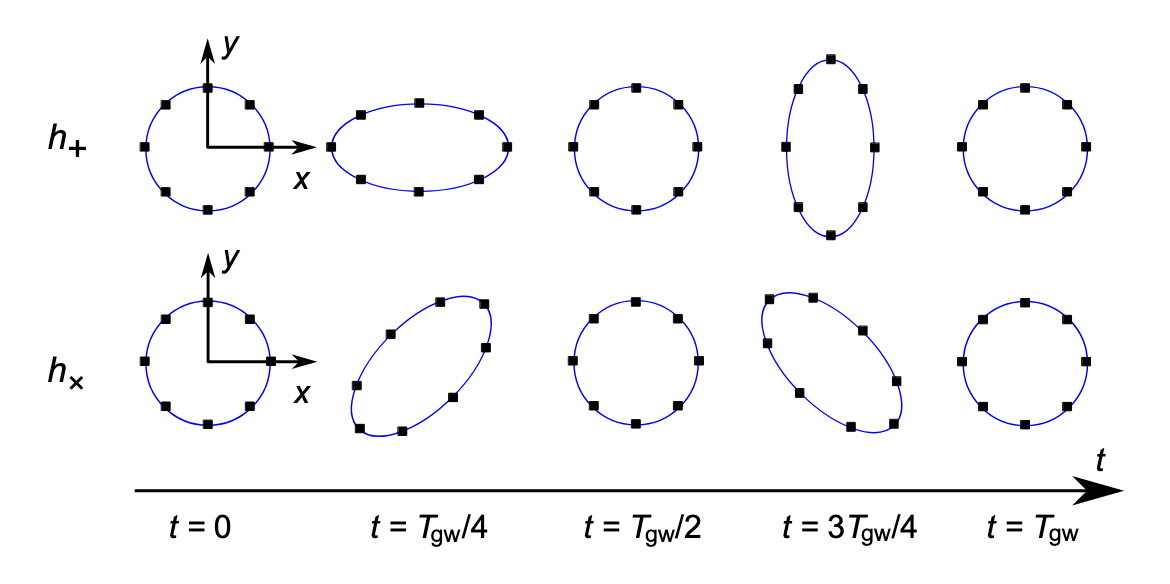 \
Fig. 1. The plus ($+$) and cross ($\times$) polarizations of a GW with an oscillation period $T_{gw}$ acting on a ring of matter. The direction of propagation is orthogonal to the screen. Adapted from [10].

We can write the spacetime metric $g_{\mu\nu} = \eta_{\mu\nu} + h_{\mu\nu}$ that describes the effect of a GW through a flat spacetime in the transverse-traceless gauge:
$$h_{\mu\nu} = \begin{pmatrix}
0 & 0 & 0 & 0 \\
0 & h_+ & h_\times & 0 \\
0 & h_\times & -h_+ & 0 \\
0 & 0 & 0 & 0 \\
\end{pmatrix}\cos(\omega t - kz).$$
This corresponds to a spacetime interval
$$ds^2 = -c^2dt^2 + (1 + h_+)dx^2 + (1-h_+)dy^2 + 2h_\times dxdy + dz^2.$$
Along a lightlike path ($ds^2 = 0$) where we consider only changes in the $x$ direction along a length $L_x$ in a time $t_0$, and assume $h_+ << 1$,
\begin{align}
cdt &= \sqrt{1 + h_+}dx \\
c\int_0^{t_0} dt &\approx \int_0^{L_x} \bigg( 1 + \frac{h_+}{2} \bigg) dx \\
ct_0 &\approx \bigg( 1 + \frac{h_+}{2} \bigg) L_x.
\end{align}
We can read this as a nominal length $L_x$ with some small linear change
$$\Delta L_x = \frac{h_+}{2}L_x.$$
Similarly, in the $y$ direction,
$$\Delta L_y = -\frac{h_+}{2}L_y.$$
We can use a Michelson interferometer to measure the differential arm length in two orthogonal directions, which we find is directly proportional to the strain $h_+$ (as long as we assume equal unperturbed arm lengths $L_x = L_y = L$):
$$h_+ = \frac{\Delta L_x - \Delta L_y}{L} = \frac{\Delta L}{L}.$$
Alternatively, we can express the length change along each arm as a change in phase of the incident laser with wavelength $\lambda$:
$$\Delta \phi(t) = k\Delta L = \frac{\pi L}{\lambda}h(t).$$

## Space-Based Detectors

Ground-based detectors are limited by the fact that they are physically anchored to the Earth, and are thus subject to noise due to motions in the Earth. Below a GW frequency of $10~\mathrm{Hz}$, these noise sources include:
- seismic noise, due to vibrations in the Earth's crust;
- Newtonian noise, due to non-uniform gravitational fluctuations in the Earth; and
- thermal noise in the test mass suspensions and coatings.

Ideally, the test masses that hold the optics of Michelson interferometers would be in freefall, eliminating the need for suspensions, seismic isolation, etc. This is the primary reason for moving our detectors to space.

### The LISA Constellation

LISA will be composed of three spacecraft (S/C) in a heliocentric orbit trailing the Earth by ~20 degrees. The satellites form a roughly equilateral triangle with side length $L \approx 2.5 \times 10^6~\mathrm{km}$. The constellation will rotate about a common center of mass with an orbital frequency of $\sim 1~\mathrm{yr}^{-1}$. 

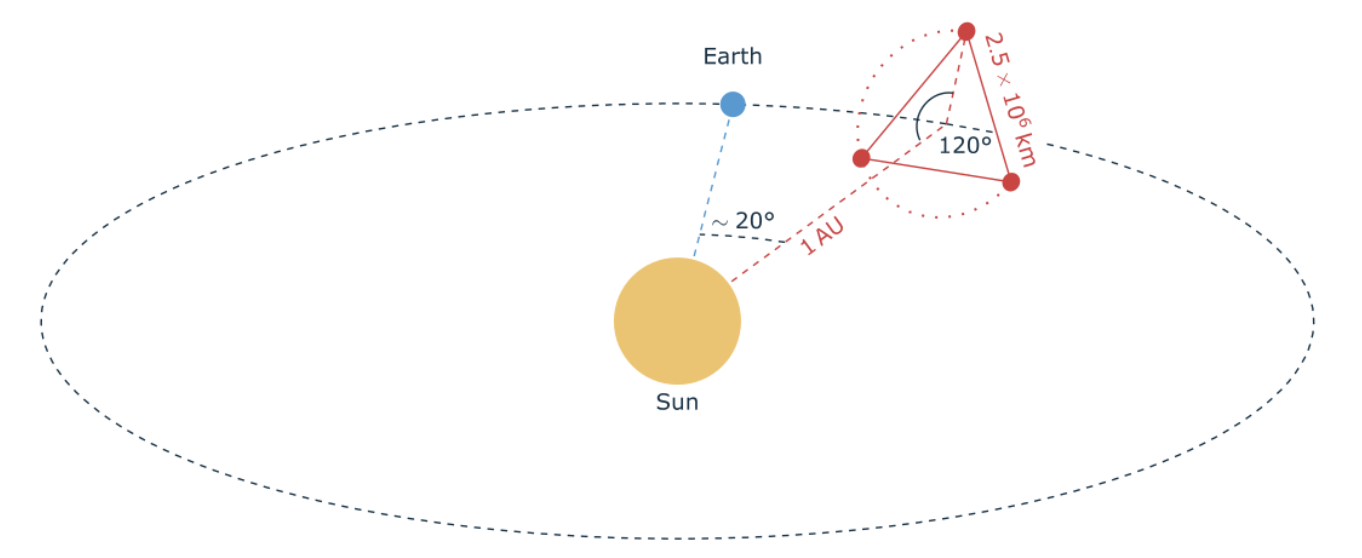

Fig. 2. Schematic of the LISA constellation relative to the Sun-Earth system. Adapted from [5].

To maintain the rough configuration of the constellation, each S/C has two micro-Newton thrusters that can minimally correct the trajectory of each satellite. Besides these small adjustments, the satellites are free-flying. LISA can tolerate a 1% ($\pm 5\times 10^5~\mathrm{m}$) variation from nominal armlength, relative rates of change in armlength of $12~\mathrm{m/s}$, and changes $< 1.5~\mathrm{deg}$ in the angles of the triangle configuration. These thresholds should be maintainable for a roughly 10-year operational period.

In [2]:
# generate a PSD for 4-second observation in LIGO
delta_f_ligo = 1/4
flen_ligo = int(16384/delta_f_ligo)
lfc_ligo = 0.1

# generate a PSD for 1-month observation in LISA
delta_f_lisa = 1/(3600*24*30)
flen_lisa = int(1/delta_f_lisa)
lfc_lisa = 1e-6

# analytic aLIGO PSD, as given in LIGO-T1800044
ligo_psd = psd.aLIGODesignSensitivityT1800044(flen_ligo, delta_f_ligo, lfc_ligo)

# simulated seismic noise based on LAL (https://lscsoft.docs.ligo.org/lalsuite/lalsimulation/group___l_a_l_sim_noise_p_s_d__c.html#ga36a762560af2474c7a6e390d8eed7096)
Sg = 1e-18 * (10/ligo_psd.sample_frequencies)**4 # displacement power spectrum of ground motion
L = 4e3 # ligo arm length
fpend = 0.6 # pendulum suspension resonant frequency
fstack = 0.6 # pendulum stack resonant frequency
nstack = 4 # number of pendula in stack
Sh = L**-2 * Sg * (fpend/ligo_psd.sample_frequencies)**4 * (fstack/ligo_psd.sample_frequencies)**(4 * nstack)

# analytic LISA PSD
lisa_psd = psd.analytical_psd_lisa_tdi_AE(flen_lisa, delta_f_lisa, lfc_lisa, tdi='1.5')

# cut off the low-frequency junk in the frequency series
ligo_low_cut = np.argmax(ligo_psd.sample_frequencies >= 1e-1)
lisa_cut = np.argmax(lisa_psd.sample_frequencies >= 1e-6)

/Users/alcorrei/miniforge3/envs/lasers/lib/python3.13/site-packages/pycbc/types/array.py:393: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [3]:
# generate a bank of templates with varying masses
params = dict(mass1 = None,
              mass2 = None,
              spin1x = 0.,
              spin1y = 0.,
              spin1z = 0.,
              spin2x = 0.,
              spin2y = 0.,
              spin2z = 0.,
              inclination = np.pi/4,
              delta_f = None,
              f_lower = None,
              approximant = 'IMRPhenomD',
              )

# same OoM as a typical BBH; m1 = m2 ~ 11.5 M_sun
mchirp = 10
params['mass1'] = mass1_from_mchirp_q(mchirp, 1)
params['mass2'] = mass2_from_mchirp_q(mchirp, 1)
params['delta_f'] = 1/mchirp
params['f_lower'] = 10/mchirp
wf = get_fd_waveform(**params)[0]

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/_r/9j158hjs4_1b8tq_l4bjwk340000gn/T/ipykernel_57061/261762800.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Amplitude Spectral Density ($\mathrm{Hz}^{-1/2}$)')
/var/folders/_r/9j158hjs4_1b8tq_l4bjwk340000gn/T/ipykernel_57061/261762800.py:23: SyntaxWarning: invalid escape sequence '\l'
  description="$\log_{10}\mathcal{M}$",


interactive(children=(FloatSlider(value=1.0, description='$\\log_{10}\\mathcal{M}$', max=8.0, readout_format='…

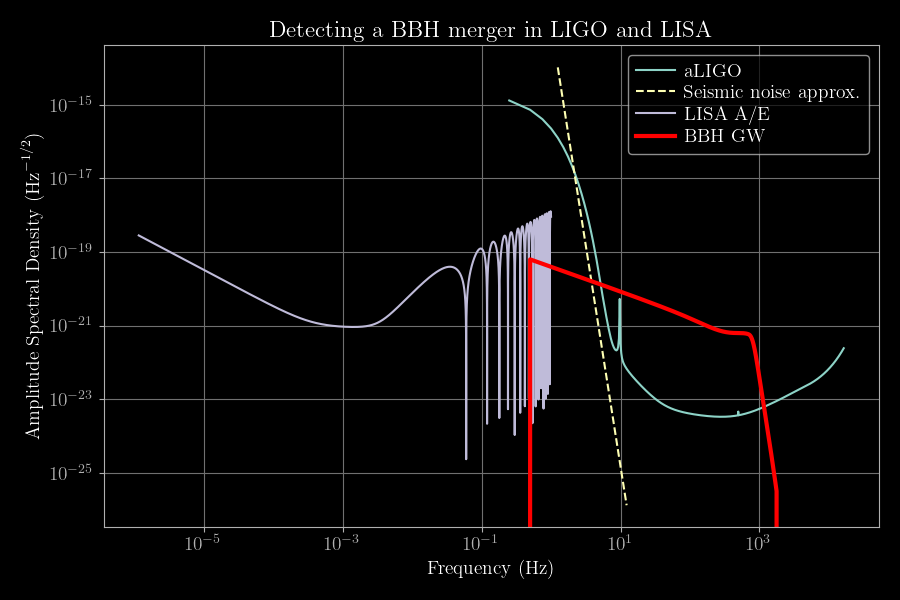

In [4]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.loglog(ligo_psd.sample_frequencies[ligo_low_cut:-1], ligo_psd[ligo_low_cut:-1]**0.5, label='aLIGO')
ax.loglog(ligo_psd.sample_frequencies[5:50], Sh[5:50]**0.5, label='Seismic noise approx.', linestyle='--')
ax.loglog(lisa_psd.sample_frequencies[lisa_cut:], lisa_psd[lisa_cut:]**0.5, label='LISA A/E')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude Spectral Density ($\mathrm{Hz}^{-1/2}$)')
ax.set_title('Detecting a BBH merger in LIGO and LISA')
# the correct way to plot this against the PSDs would be to pass it through the detector response
# that's really slow and cumbersome, plus it wouldn't be transferrable across detectors (i.e. we'd have to switch response fns)
# so instead I'm just dividing by a mass factor to get the amp kind of right
line, = ax.loglog(wf.sample_frequencies, 2*abs(wf)*np.sqrt(wf.sample_frequencies)/10, label='BBH GW', color='red', lw=3)
ax.grid()
ax.legend()

mc_slider = FloatSlider(
    value=1,
    min=0,
    max=8,
    step=0.1,
    description="$\log_{10}\mathcal{M}$",
    continuous_update=True,  # Only update on release for better performance
    orientation='horizontal',
    readout=True,
    readout_format='.3f',
)

def update(mc_slider_value = 1):
    logmc = mc_slider_value
    mc = 10**logmc
    m1 = mass1_from_mchirp_q(mc, 1)
    m2 = mass2_from_mchirp_q(mc, 1)
    df = 1/mc
    fmin = 5/mc
    params['mass1'] = m1
    params['mass2'] = m2
    params['delta_f'] = df
    params['f_lower'] = fmin

    new_wf = get_fd_waveform(**params)[0]
    line.set_xdata(new_wf.sample_frequencies)
    line.set_ydata(abs(new_wf)*np.sqrt(new_wf.sample_frequencies)/mc)
    fig.canvas.draw_idle()

    print(f'Binary total mass: {2*mass1_from_mchirp_q(mc, 1):.3e}')
    return

interact(update, mc_slider_value=mc_slider)
plt.show()

## Interferometry

Three levels of interferometry are conducted by LISA. Each S/C emits two lasers to the other satellites, creating a network of six _long-arm_ or _inter-satellite interferometers_ (ISIs). Additionally, each S/C contains two onboard _short-arm_ or _test mass interferometers_ (TMIs) that detect fluctuations in the test mass positions. A _reference interferometer_ (RFI) on each optical bench is used to compare the positions of the test masses to each other.

### Inter-Satellite Interferometer

Each S/C emits two $2~\mathrm{W}$ lasers at $1064~\mathrm{nm}$, each of which is aimed at one of the other two S/C to measure the distance between inter-satellite optical benches. The direction of each beam is controlled using a Point-Ahead-Angle-Mechanism (PAAM), which sets the angle between the received and transmitted beams between two S/C. The angle is determined by the S/C trajectories and the angle of the received beam, which records the angular position of the emitting S/C $\sim 8.3~\mathrm{s}$ ago. Angles are updated based on the maximum point-ahead angle drift (on the order of minutes to hours) to maintain nanoradian accuracy [7].

Each S/C is mounted with two telescopes that both transmit beams to and receive beams from the other spacecraft. Transmitted beams are generated with a diameter of $\sim 2.24~\mathrm{mm}$ and are magnitifed to a collimateed beam of $\sim 300~\mathrm{mm}$ diameter; the dilation is reversed for indicent beams. The optics of the telescope will be heated to room temperature to match ground-testing conditions.

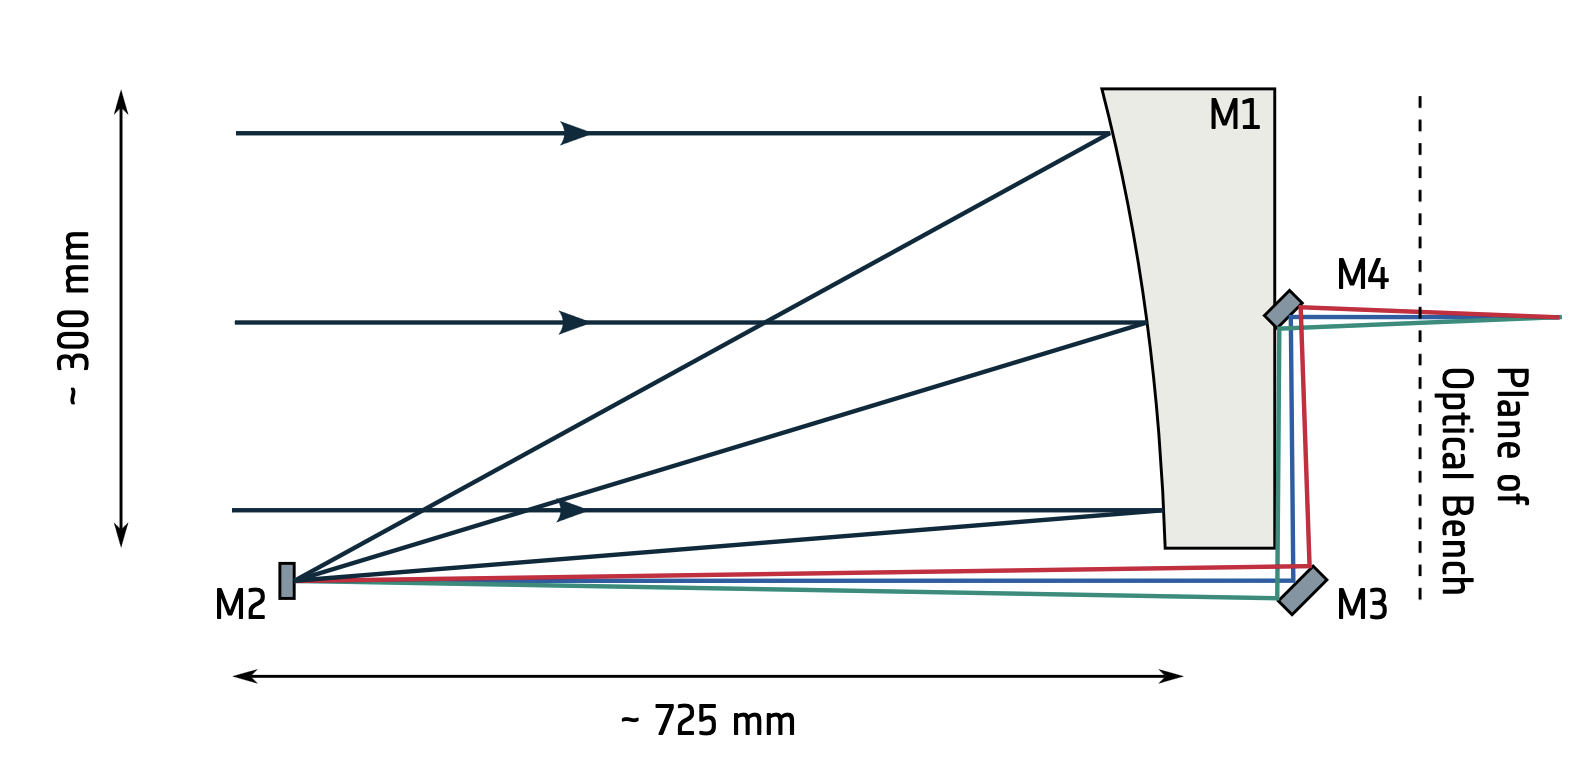

Fig. 3. Design for one of the LISA telescopes focusing an incident beam with a $300~\mathrm{mm}$ diameter. M1 through M4 are mirrors that increasingly focus and collimate the beam to $2.24~\mathrm{mm}$. The angle of incidence for the parabolic mirror (M1) is intentionally off-axis to prevent backscattering of coherent light to the receiver (a "Narcissus reflection") that overwhelms the power of the incident beam. M2 is a hyperbolic mirror that further refines the beam diameter. M3 and M4 collimate the beam before being received by the optical bench. Adapted from [5].

### Test-Mass Interferometer

In addition to the ISIs, each S/C will use interferometry to monitor the positions of two on-board free-falling test masses, which act as inertial references for the positions of the optical benches. The test masses form part of the Gravitational Reference System (GRS), which determines potential adjustments that need to be made to the position of each of the six Moving Optical Sub-Assemblies (MOSAs).

Each test mass is a $1.92~\mathrm{kg}$ $44~\mathrm{mm}$ cube of Au-Pt, designed to be electrostatically stable and polished to a mirror finish. The test masses are stored in a $600~\mathrm{mm}$ vacuum tube that operates at no more than $2~\mathrm{\mu Pa}$. Additional gravitational balance masses to isolate the test masses from the gravitational attraction of other S/C components. These balances need to be able to balance out gravitational forces to within $\sim 10^2~\mathrm{pm~s^{-2}}$ of translational acceleration and $1~\mathrm{nrad~s^{-2}}$ of angular acceleration.

Each face contains an electrode, through which an AC voltage of $4.9~\mathrm{V}$ at frequency $3 \times 2^{15}~\mathrm{Hz}$ is applied, resulting in a contact-free potential difference of amplitude $0.6~\mathrm{V}$. Rotational and translational displacements of the test mass result in voltage differentials across the cube, which are measured and processed by sensing electrodes in the test mass housing. 

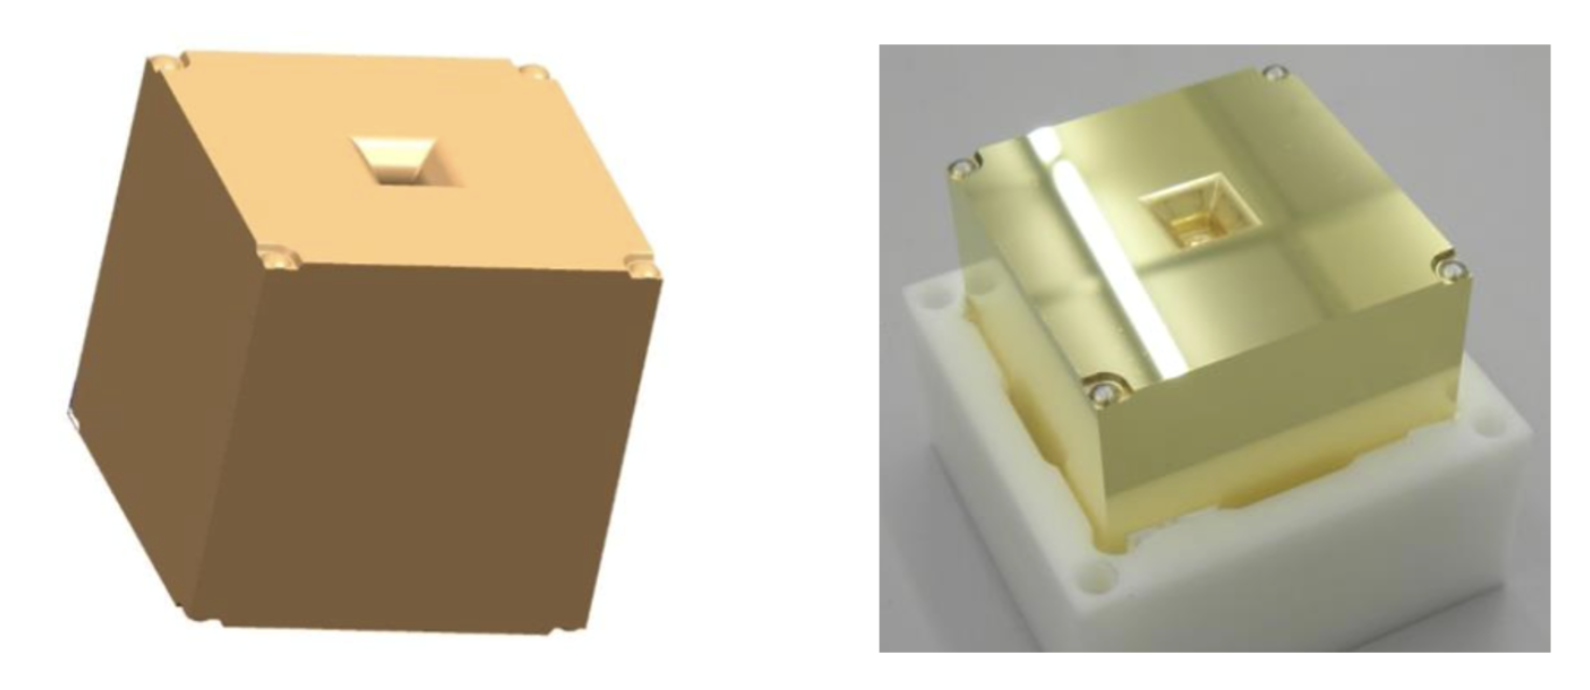

Fig. 4. The LISA test mass deployed in the LISA Pathfinder mission, as seen in CAD (left) and real life (right). Adapted from [5].

If the test masses become angularly misaligned, a torque actuation system applies electrostatic forces. Voltages for torque applications are deployed in the audio ($50 - 300~\mathrm{Hz}$) range, pulling on the test mass from both ends to make readjustments. 

Ideally, the test masses along the direction of laser propagation (i.e. the dimension along which GW strains are measured, aka the _sensitive axis_) should behave as if in freefall. This is similar to locking a ground-based GW observatory; in the absense of GWs the end mirrors should be approximately stationary. To preserve the position and orientation of the test masses, a Drag-Free Attitude Control System (DFACS) is used. If the test masses deviate from their freefall positions, DFACS will reposition the S/C using the mounted micro-Newton thrusters.

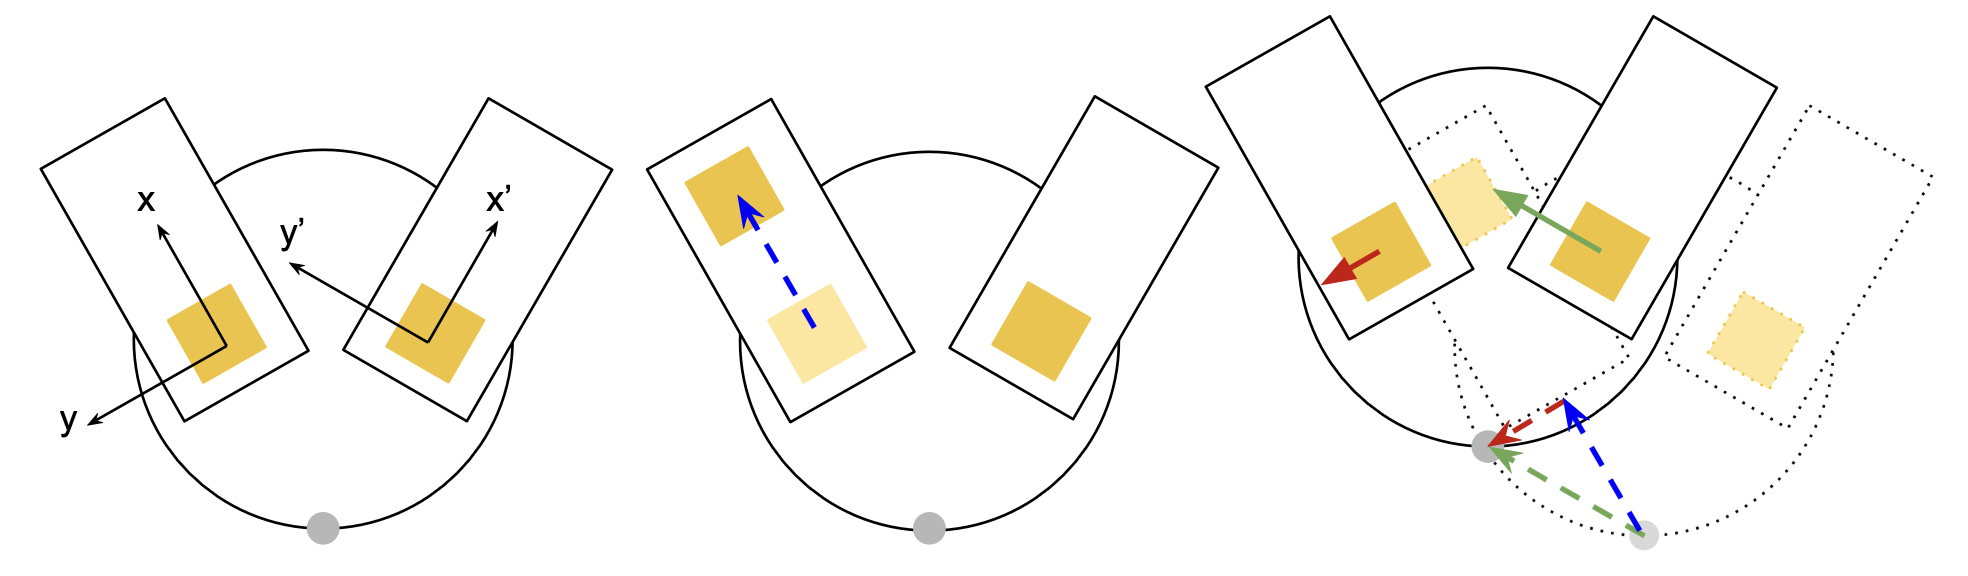

Fig. 5. Schematic of the DFACS algorithm. Left: the two test masses (yellow squares) are in freefall relative to the MOSAs (black rectangles). The sensitive axes (i.e. the axes of incident laser propagation) are along $x$/$x'$; the insensitive axes are along $y$/$y'$. Center: one of the test masses is displaced along the sensitive axis (blue arrow). Right: DFACS evaluates a change in S/C position (green arrow) such that the left test mass is returned to freefall along the $x$ while the right test mass is only moved along $y'$ (red arrow). Adapted from [5].

### Reference Interferometer

An additional interferometer is used to measure the relative phases between the MOSAs on one S/C. This is done to partially cancel out any noise fluctuations that could occur due to changes in S/C orientation (i.e., angular displacements). A backlink fiber is used to exchance laser signals between MOSAs.

All three interferometers measure phase using beatnotes, combining the incident measurement lasers with local oscillators. This is especially important for the ISI due to the extreme power loss when travelling across the arms (for every $1~\mathrm{W}$ transmitted, roughly $300~\mathrm{pW}$ are received; this is due to the diameter of the beam expanding as it travels between S/C).

### Optical Bench

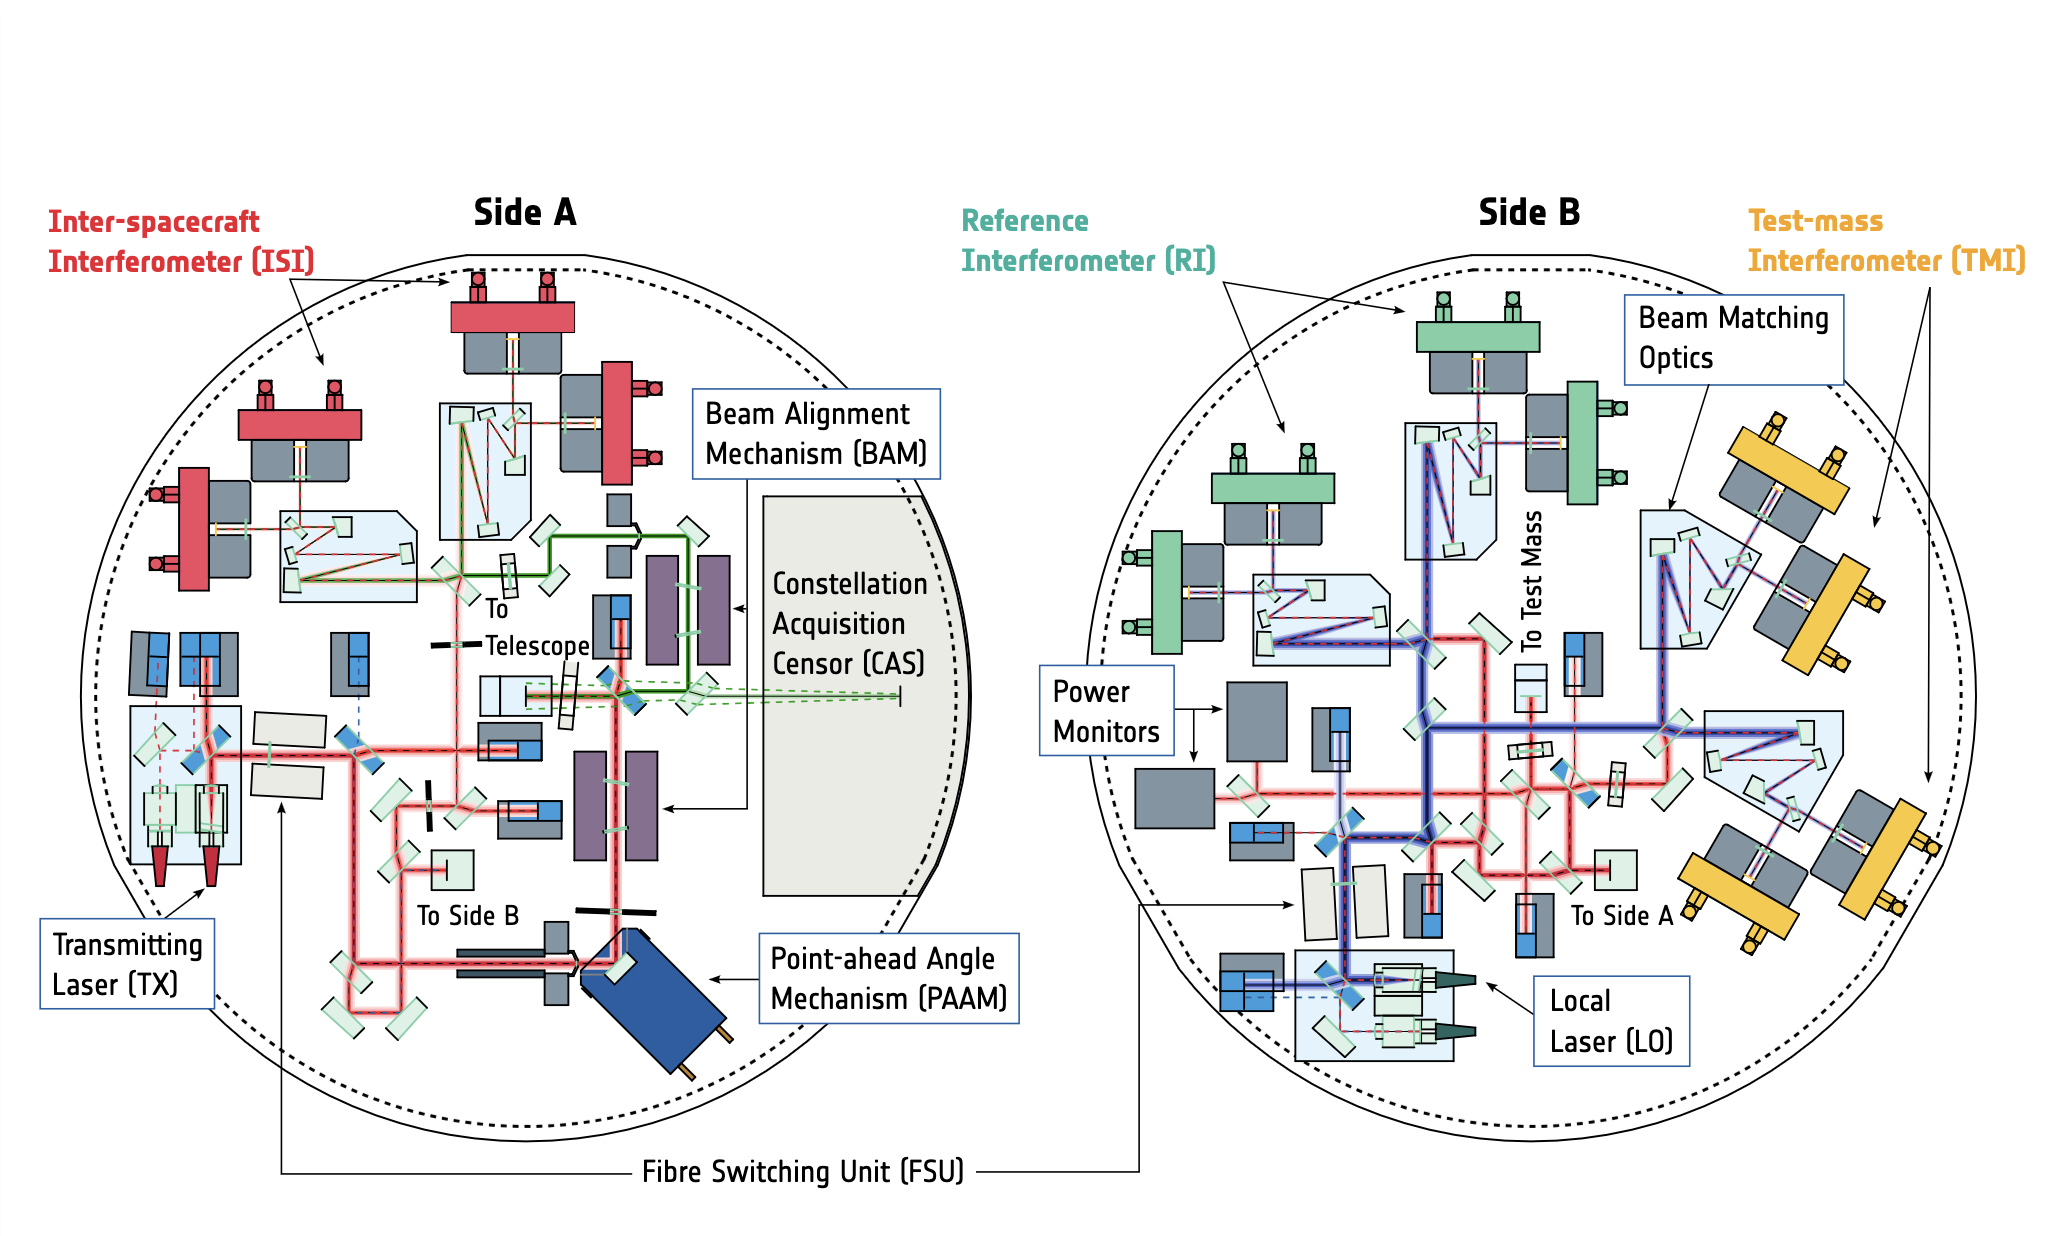

Fig. 6. Diagram of the optical bench for LISA. The bench is two-sided; one side houses the transmitting laser emitter and ISI (red IFO), and the other houses the local laser oscillator (purple), TMI (yellow IFO), and RFI (green IFO). Side A has a port that sends/receives the transmitting (red)/received (green) laser to/from the telescope. Side B sends and receives the transmitting laser for reflecting off the test mass. Each interferometer arm sends incident light to two quadrant photoreceivers (QPRs) to detect optical beatnotes. Fiber-switching units (FSU) are implemented to switch between the optical fibers that deliver the generated lasers to the rest of the optical bench; these are intended only for use before deployment and in case of emergencies. Adapted from [5].

To review from the figure above:
- The ISI measures the beatnote between the laser transmitted from another S/C and a local oscillator, which will eventually be transmitted back to the other satellites.
- The local oscillator is wired to the other side of the optical bench via backlink fiber, reflected off the test mass, and recombined with another local oscillator to measure a beatnote in the TMI.
- The RFI measures the beatnote between the transmitted beam and the local oscillator without reflecting off the test mass.

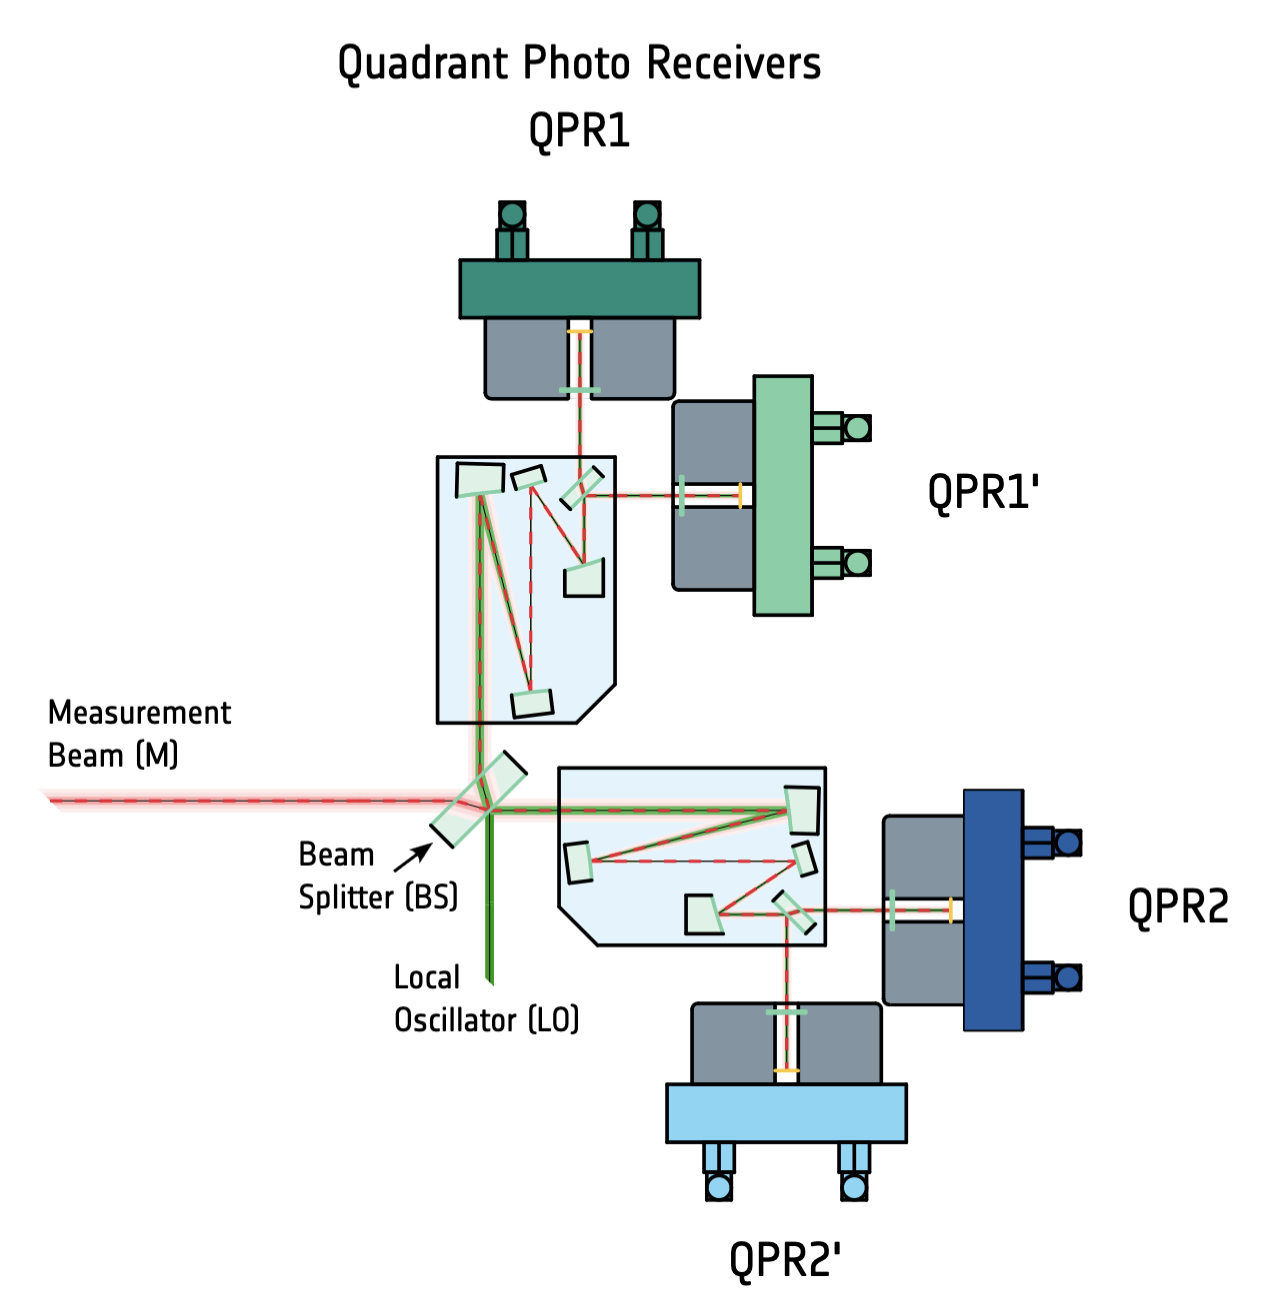

Fig. 7. Close-up of the QPR setup at each IFO arm. These measure the beatnotes between a local oscillator (green) and a measurement beam (red) in each IFO. Adapted from [5].

## One-Way IFO Response

Consider the laser link travelling from S/C 2 to S/C 1. The laser travels along the arm length $L_3(t)$ (labelled by the opposite S/C index). The laser is emitted at $t=t_{send,2}$, at which the CoM of S/C 2 is located at $\vec{x}_2(t_{send,2})$. The laser is received at $t=t_{recv,1}$, further defined as
$$t_{recv,1} = t_{send,2} + \frac{L_3(t_{recv,1})}{c}.$$
The local laser is generated with a nominal frequency $\omega_1$. The electric field $E_1$ due to the local laser therefore has a total phase equal to the unperturbed laser phase $\phi_{Laser,1}$ plus any phases $\phi_{n,1}$ due to uncertainties along the path length:
$$E_1(t_{recv,1}) \propto \frac{i}{\sqrt{2}}\exp( i [\phi_{Laser,1}(t_{recv,1}) + \phi_{n,1}(t_{recv,1})] ).$$
(The factor $i/\sqrt{2}$ assumes a perfect beamsplitter in the IFOs and a $\pi/2$ polarization rotation to align the recombined beams.) We can rewrite
$$\phi_{Laser,1}(t_{recv,1}) = \omega_1 t_{recv,1} + p_1(t_{recv,1}),$$
where $\omega_1$ is the frequency of the laser and $p_1$ indicates phase uncertainty due to laser frequency noise. So,
$$E_1(t_{recv,1}) \propto \frac{i}{\sqrt{2}}\exp( i [\omega_1 t_{recv,1} + p_1(t_{recv,1}) + \phi_{n,1}(t_{recv,1})] ).$$
The electric field $E_2$ of the laser incident has four components: optical path length variations in S/C 2, the total nominal phase shift across the arm length, optical path length variations in S/C 1, and optical path length variations (including GW strain) between the optical boards:
$$E_2(t_{recv,1}) \propto \frac{1}{\sqrt{2}}\exp( i [\phi_{n,2}(t_{send,2}) + \phi_{Laser,2}(t_{recv,1}) + \phi_{n,1}(t_{recv,1}) + \phi_{2\rightarrow1}(t_{recv,1})] ).$$
The phases here are more complicated; the laser undergoes a Doppler shift $\omega_2 \rightarrow \omega'_2$ due to the relative motion across the arm. Thus,
$$E_2(t_{recv,1}) \propto \frac{1}{\sqrt{2}}\exp( i [\omega'_2t_{recv,1} + p_2(t_{send,2}) + \phi_{n,2}(t_{send,2}) + \phi_{n,1}(t_{recv,1}) + \phi_{2\rightarrow1}(t_{recv,1})] ).$$
These fields are recombined such that, if we rewrite the total phases due to noise and GW strain as $\phi_i(t)$ ($t$ being an arbitrary _constellation time_ common to all S/C), the incident power is
\begin{align}
P(t) &\propto |E_1(t) + E_2(t)|^2 \\
&= 1 + \frac{1}{2}\exp[i(\omega'_2t + \phi_2(t))]\exp[-i(\omega_1t + \phi_1(t))] + \frac{1}{2}\exp[-i(\omega'_2t + \phi_2(t))]\exp[i(\omega_1t + \phi_1(t))] \\
&= 1 + \frac{1}{2}\exp[i((\omega'_2 - \omega_1)t + (\phi_2(t) - \phi_1(t))) ] + \frac{1}{2}\exp[-i((\omega'_2 - \omega_1)t + (\phi_2(t) - \phi_1(t))) ] \\
&= 1 + \cos [(\omega'_2 - \omega_1)t + \phi_2(t) - \phi_1(t)].
\end{align}
We can now define heterodyned quantities
$$\omega_{het,1} = \omega'_2 - \omega_1$$
$$\Delta \phi_1(t) = \phi_2(t) - \phi_1(t)$$
such that the power can be rewritten as
$$P(t) \propto \cos(\omega_{het,1}t + \Delta \phi_1(t)).$$
The observable we wish to measure is encoded in $\Delta \phi_1(t)$. The _science interferometer_ phase $\bar{s}_1(t)$ is equivalent to $\Delta \phi_1$, where we identify $\phi_{2 \rightarrow 1}$ as the GW signal projected to the laser link $H_1(t)$, and optical bench phase noises $\phi_{OB,1}$ and $\phi_{OB,2}$. The phase $\phi_{n,2}$ is translated to an overall phase readout noise $\phi_{Noise,1}$ evaluated at the receiver time, which gives:
$$\bar{s}_1(t) = H_1(t) + p_2\bigg( t - \frac{L_3(t)}{c} \bigg) - p_1(t) + \phi_{OB,2}\bigg( t - \frac{L_3(t)}{c} \bigg) + \phi_{OB,1}(t) + \phi_{Noise,1}(t).$$
The optical path length noises can be expressed in terms of the OB1 displacement $\vec{\Delta}_1$ along the direction of propagation $\vec{n}_{3'}$ and the OB2 displacement $\vec{\Delta}_1$ in the direction of anti-propagation $\vec{n}_{3}$. Thus,
$$\bar{s}_1(t) = H_1(t) + p_2\bigg( t - \frac{L_3(t)}{c} \bigg) - p_1(t) - \frac{2\pi}{\lambda'_2}\vec{n'}_3(t) \cdot \vec{\Delta}_2 \bigg( t - \frac{L_3(t)}{c} \bigg) - \frac{2\pi}{\lambda_1}\vec{n}_{3}(t) \cdot \vec{\Delta}_1 (t) + \phi_{Noise,1}.$$
(The negative signs in the displacement terms indicate that positive motion along the vectors leads to a decrease in the total length of the arm.)

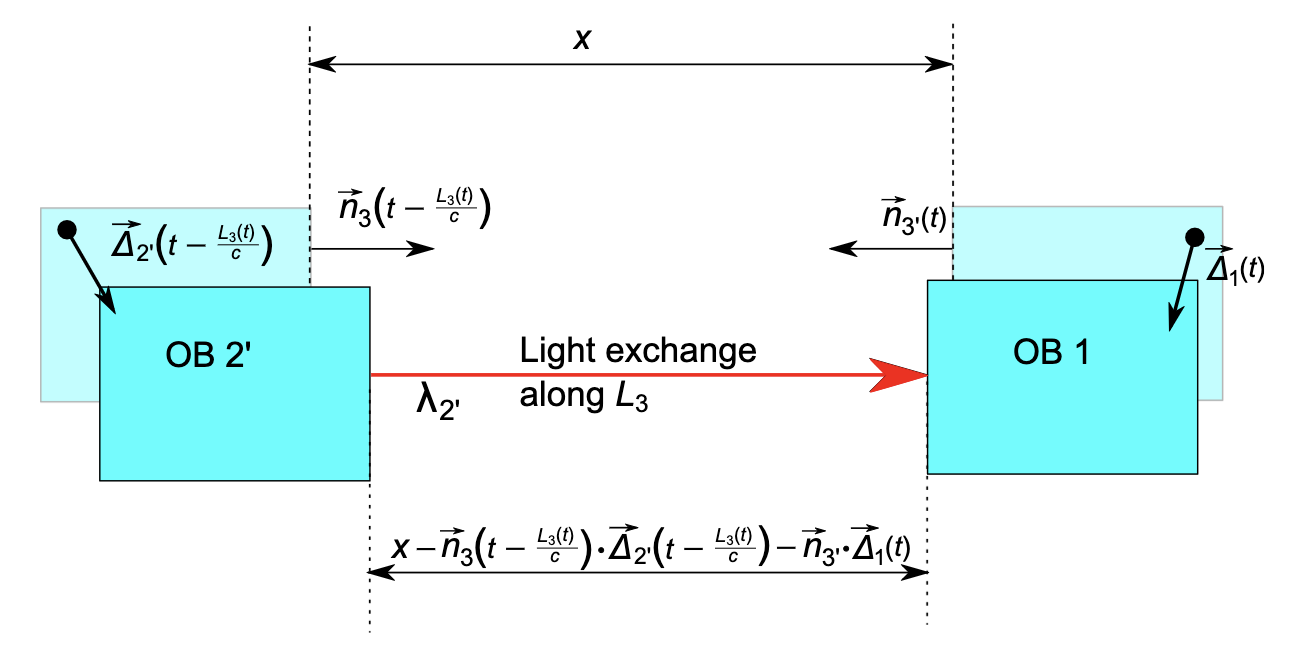

Fig. 8. Schematic of optical bench displacements along the direction of inter-spacecraft transmission. Adapted from [10].

The total phase $\bar\epsilon_1$ measured by the TMI consists of the laser frequency phases $p_1$ of the local oscillator and $p_{1'}$ of the transmitting beam. A fiber noise $\mu_{1'}$ is accrued during propagation of the transmitting beam along the backlink fiber. The noise due to readout is summarized by an additional phase $N_1^{\epsilon}$. Displacement noise of the test mass $\vec \delta_1$ and optical board $\vec \Delta_1$ in the direction $\vec n_{3'}$ give rise to an additional relative optical phase. Thus, the TMI measures a total phase
$$\bar{\epsilon}_1(t) = p_{1'}(t) - p_1(t) + 2 \bigg( \frac{2\pi}{\lambda_1}\vec n_{3'}(t) \cdot \vec \delta_1(t) - \frac{2\pi}{\lambda_1}\vec n_{3'}(t) \cdot \vec \Delta_1(t) \bigg) + \mu_{1'}(t) + N_1^{\epsilon}(t).$$
(The factor of 2 in the third term comes in due to reflection off of the test mass, so path length changes apply twice. Displacements are defined positive in the direction of $\vec n_{3'}$, so test mass displacements will increase the path length while optical bench displacements decrease the length; see below.)

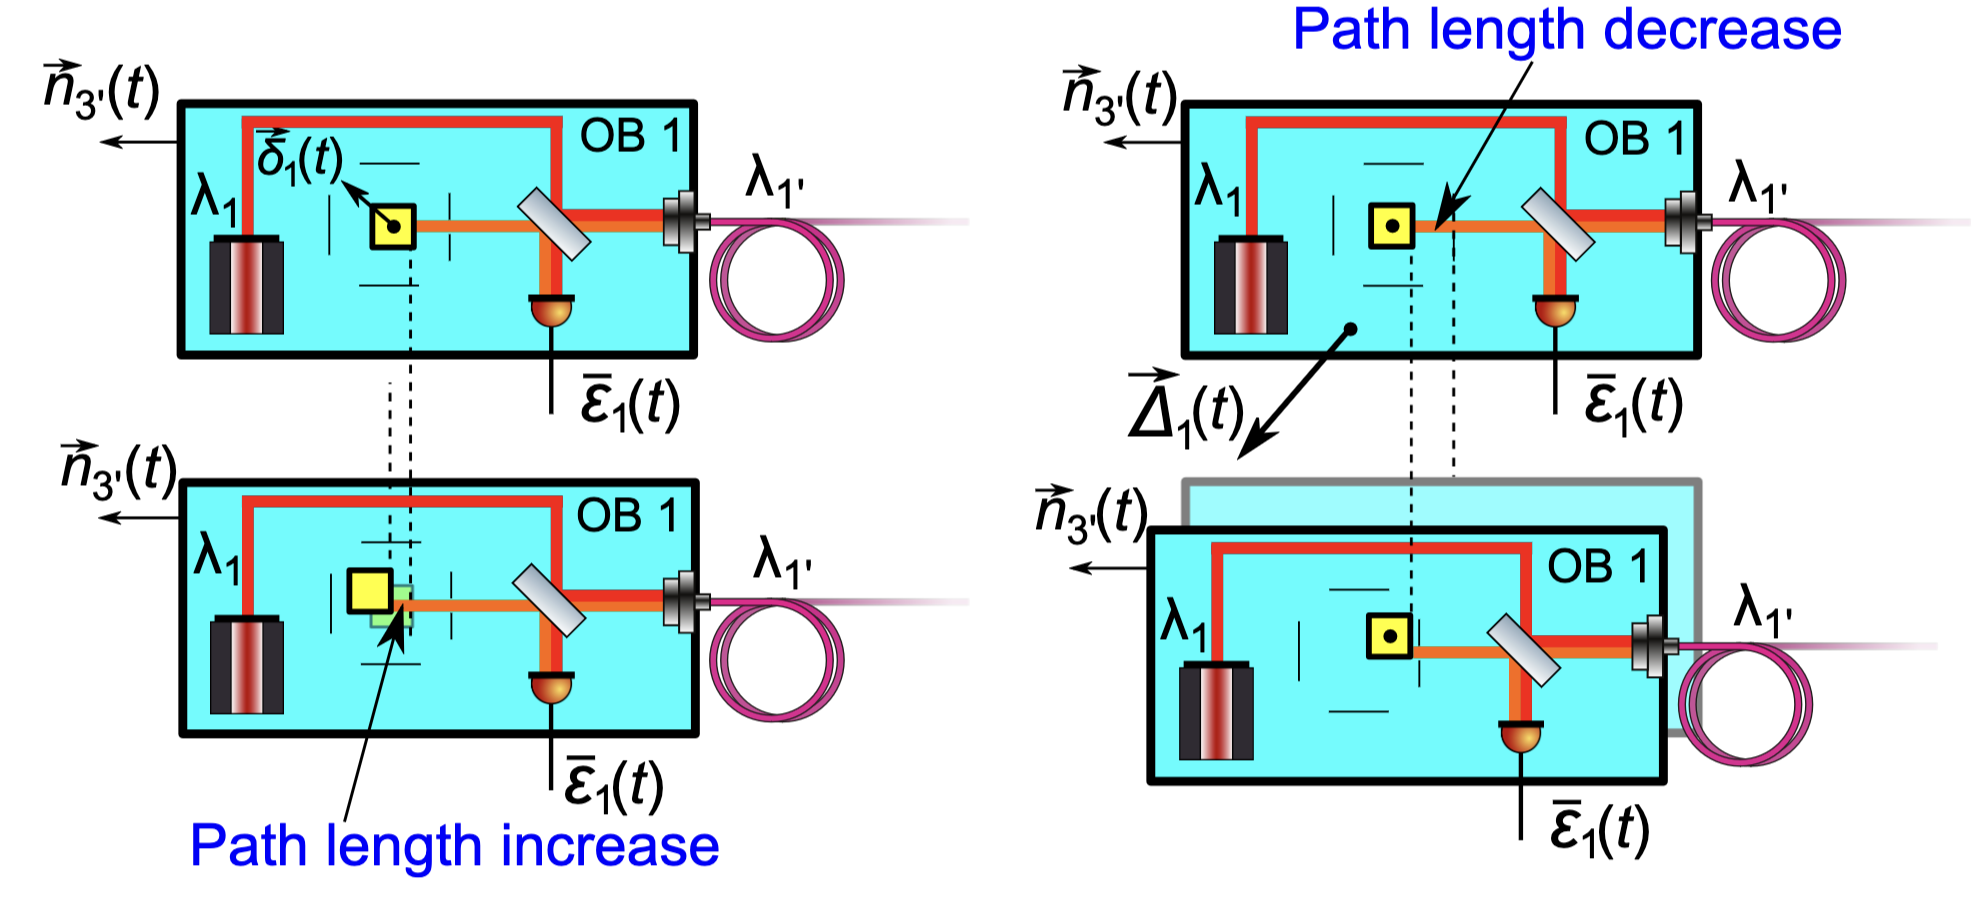

Fig. 9. Schematic of optical path length noises measured by the TMI. Adapted from [10].

Finally, the phase $\bar \tau_1$ measured by the RFI combines the laser phases $p_1$ and $p_{1'}$, the fiber noise $\mu_{1'}$, and readout noises $N_1^\tau$:
$$\bar \tau_1(t) = p_{1'}(t) - p_1(t) + \mu_{1'}(t) + N_1^{\tau}(t).$$
Thus, there are three phases measured on each of the six optical benches at constellation time $t$. These can be combined to cancel out the known analytic noise terms and obtain six observable strains $H_i(t)$ due to GW incidence along with unavoidable readout and optical path length noises.

## Noise Sources

While the three-interferometer scheme gives us a way to discern the GW strain robustly, there are still inevitable noise sources that will come into any LISA measurements. The noise contributions can be grouped into three categories
- acceleration noise, due to uncertainties in the motion of the test masses;
- optical metrology system (OMS) noise, due to readout uncertainties in the interferometers; and
- laser frequency noise.

### Acceleration Noise

Discrepancies in the trajectories of the test masses from freefall geodesics will be the primary contributor to low-frequency ($\lesssim 4~\mathrm{mHz}$) noise. Brownian motion is a white noise source that persists throughout the entire frequency range. At low frequencies, residual forces due to stray electromagnetic fields, gravitational coupling with the rest of the S/C, and thermal interactions begin to dominate, scaling at least with $f^{-1}$. The LISA Data Challenges (LDC) use an analytic model based on LISA Pathfinder results and ground-based development to establish a threshold for the acceleration noise ASD
$$S^{1/2}_{acc}(f) \leq 3\times10^{-15} \frac{\mathrm{m}}{\mathrm{s}^2 \sqrt{\mathrm{Hz}}} \sqrt{1 + \bigg( \frac{0.4~\mathrm{mHz}}{f} \bigg)^2}\sqrt{1 + \bigg( \frac{f}{8~\mathrm{mHz}} \bigg)^4}, 20 \mu\mathrm{Hz} \leq f \leq 1~\mathrm{Hz}.$$

All of the controls to adjust the position of the test masses were tested during the LISA Pathfinder mission, which ran from 2015 to 2017. The mission launched a satellite about the Earth-Sun $L_1$ point with two test masses (effectively mimicking one S/C of the full LISA design), with the goal of obtaining a constraint on the differential acceleration noise $\Delta g$ measurable by the TMIs. By the end of the mission, LISA Pathfinder achieved a noise ASD of $5.2 \pm 0.1~\mathrm{fm~s}^{-2}/\sqrt{\mathrm{Hz}}$ in the $0.7-20~\mathrm{mHz}$ range; this is a factor of 5 lower than expected and within order unity of the requirements for the actual LISA mission.

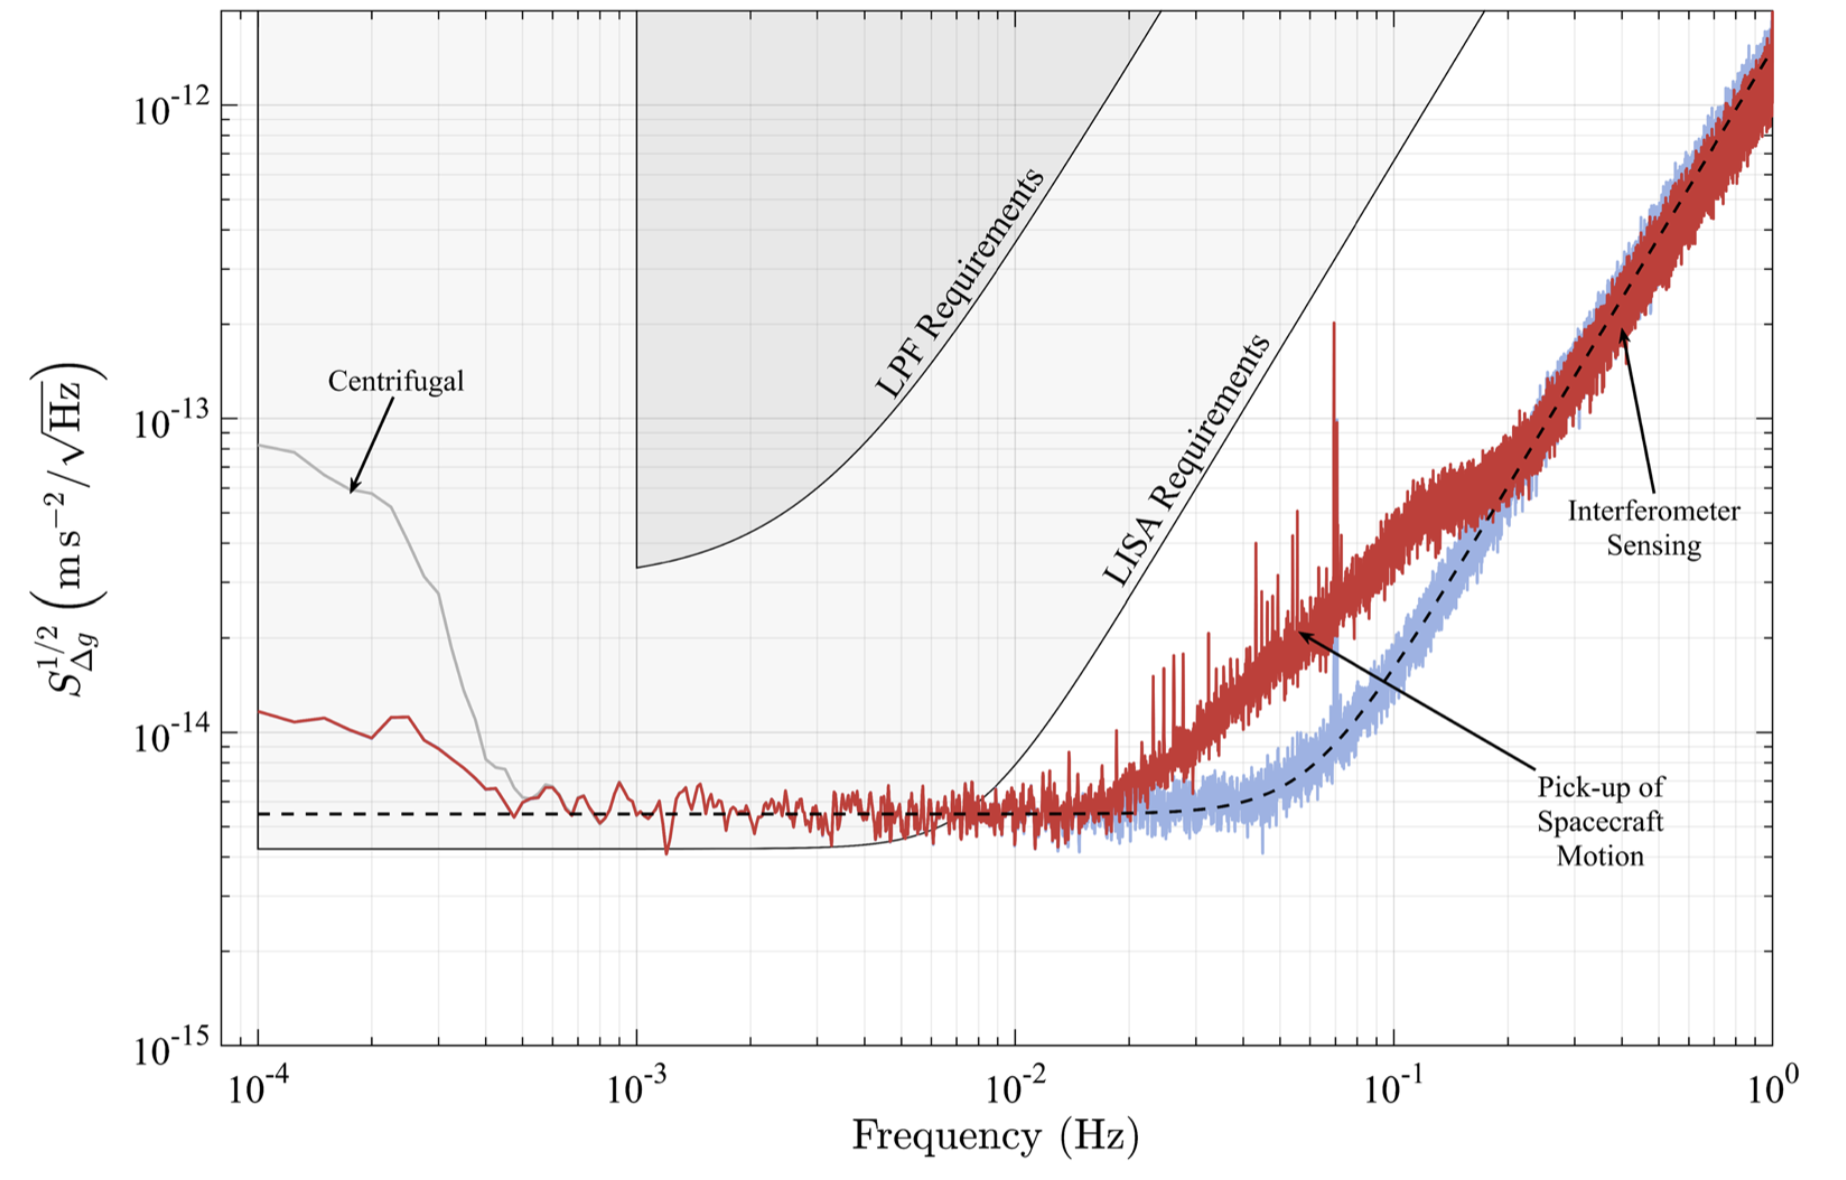

Fig. 10. The amplitude spectral density (ASD) of differential acceleration noise measured by LISA Pathfinder over a 6.5 day period. The raw ASD is shown with a gray line. The red line analytically corrects for noise due to the centrifugal force as the satellite rotates, which contributes to low-frequency noise. The blue line analytically accounts for additional S/C rotational/translational motion picked up by the TMIs. The high-frequency noise is dominated by readout noise in the interferometers. Shaded regions indicate the science requirements set forth for the Pathfinder mission (dark gray) and the actual LISA mission (light gray). Adapted from [2].

### OMS Noise

Additional noise is present throughout the frequency band due to uncertainties in the interferometric phase measurements. This also scales up at low frequencies, but tends toward white noise at high frequencies. This can be simulated as a quadrature sum of shot noise, electronic noise (i.e. noise in photodiode measurements), and relative intensity noise due to laser power fluctuations. The analytic model employed by the LDC for the ideal OMS noise is described by
$$S^{1/2}_{oms}(f) \leq 10^{-11} \frac{\mathrm{m}}{\sqrt{\mathrm{Hz}}} \sqrt{1 + \bigg( \frac{2~\mathrm{mHz}}{f} \bigg)^4}, 20 \mu\mathrm{Hz} \leq f \leq 1~\mathrm{Hz}.$$

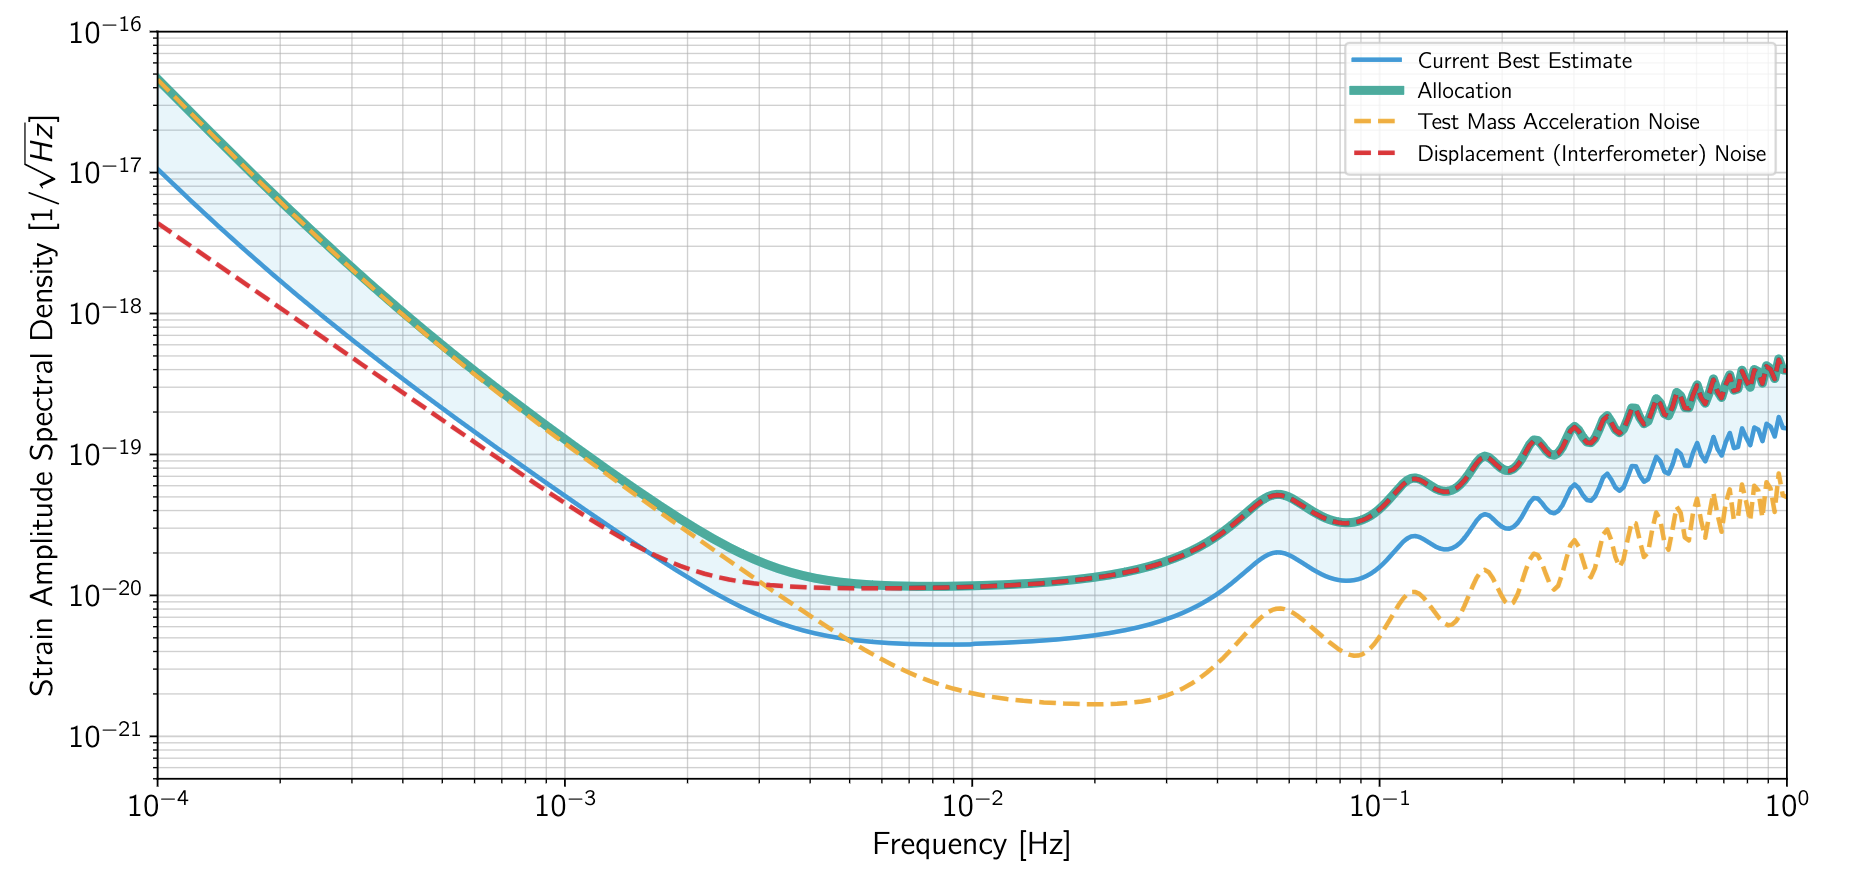

Fig. 11. Noise budget of LISA expressing sensitivity to GWs, expressed as a GW strain ASD averaged over all source sky locations and orientations. Green and blue solid lines indicate the LISA science requirement and goal, respectively. A red dashed line indicates the total OMS noise. A yellow dashed line indicates the total acceleration noise. The rise and "wiggling" at high frequencies reflects the coupling between GW strains and the combined IFO measurements. Adapted from [5].

### Laser Frequency Noise

The noise source with by far the largest impact on LISA measurements is due to uncertainties in laser frequency upon generation. In an ideal Michelson interferometer, the $X$ and $Y$ arms will measure a time-dependent phase due to incident GWs $H_i$ projected to the $i$th arm, uncertainty in the output laser frequency $p$, and additional measurement noise $\phi_n,i$:
\begin{align}
\Phi_X &= H_X(t) + \omega\bigg(t - \dfrac{2L_X}{c}\bigg) + p\bigg(t - \dfrac{2L_X}{c}\bigg) + \phi_{n,X}(t) \\
\Phi_Y &= H_Y(t) + \omega\bigg(t - \dfrac{2L_Y}{c}\bigg) + p\bigg(t - \dfrac{2L_Y}{c}\bigg) + \phi_{n,Y}(t). \\
\end{align}
The total DARM phase accrued and measured by the AS port is
\begin{align}
\Phi_{AS}(t) &= \Phi_X(t) - \Phi_Y(t) \\
&= H_X(t) - H_Y(t) + \omega\bigg(t - \dfrac{2L_Y}{c} - \dfrac{2L_X}{c}\bigg) + p\bigg(t - \dfrac{2L_X}{c}\bigg) - p\bigg(t - \dfrac{2L_Y}{c}\bigg) + N(t) \\
&= H_X(t) - H_Y(t) + \omega\bigg(t - \dfrac{2\Delta L}{c} - \dfrac{2L_X}{c}\bigg) + p\bigg(t - \dfrac{2L_X}{c}\bigg) - p\bigg(t - \dfrac{2(L_X + \Delta L)}{c}\bigg) + N(t),
\end{align}
defining $\Delta L = L_Y - L_X$ and collecting all secondary measurement noise phases under $N(t)$. For nonzero DARM, we can estimate the equivalent noise strain as
$$\frac{\tilde{x}(f)}{\Delta L} = \frac{\tilde \nu (f)}{\nu},$$
where $\nu$ is the nominal laser frequency, $\tilde x$ is the linear spectral density of the arm length uncerainty, and $\tilde \nu$ is the uncertainty in laser frequency. This equation can be converted to a phase linear spectral density based on the nominal wavelength $\lambda$ of the laser:
\begin{align}
\tilde \phi(f) &= \frac{2\pi}{\lambda}\tilde x(f) \\
&= \frac{2\pi}{\lambda}{\Delta L}\frac{\tilde \nu (f)}{\nu} \\
&= \frac{2\pi\Delta L}{c}\tilde \nu (f).
\end{align}
The long-arm interferometers combine laser light from the arms with the local oscillators, giving a differential arm length $\Delta L \sim 10^9~\mathrm{m}$. Even with the allowed laser frequency uncertainty $\tilde \nu \sim 100~\mathrm{Hz}/\sqrt{\mathrm{Hz}}$, this leads to a prohibitively high phase linear spectral density:
$$\tilde \phi(f) \sim \frac{2\pi}{c} (10^9~\mathrm{m}) (100~\mathrm{Hz}/\sqrt{\mathrm{Hz}}) \sim 10^3 \frac{\mathrm{rad}}{\sqrt{\mathrm{Hz}}}.$$
For a $1064~\mathrm{nm}$ laser, this corresponds to an uncertainty in arm length
$$\Delta \tilde x = \frac{\lambda}{2\pi}\Delta \tilde \phi \sim 10^{-4}~\frac{\mathrm{m}}{\sqrt{\mathrm{Hz}}}.$$
Meanwhile, a typical LISA GW signal will induce length changes of $\lesssim 10^{-10}~\mathrm{m}$ -- 6 orders of magnitude below the displacement due to raw frequency noise.

## Time Delay Interferometry

So, some level of post-processing is required to get any amount of useful information out of LISA measurements. This is known as _time-delay interferometry_ (TDI). By combining the different laser links as measured at different times, we can effectively cancel out the laser frequency uncertainty while preserving the GW signal.

### Basic Principle

To get a feel for how TDI works we consider the configuration below. A laser with frequency uncertainty $p$ is emitted and split equally to two IFOs. Each IFO is unequal-arm, with long arm lengths $L_1$ and $L_2$ that are fixed in time. As above, at constellation time $t$ the phase contribution $y_{PD,i}$ along each arm $i$ consist of GW strain $H_i$, laser frequency uncertainty $p$, and auxilliary noises $N_i$:
\begin{align}
y_{PD,1}(t) &= H_1(t) + p(t - T_1) - p(t) + N_1(t) \\
y_{PD,2}(t) &= H_2(t) + p(t - T_2) - p(t) + N_2(t).
\end{align}

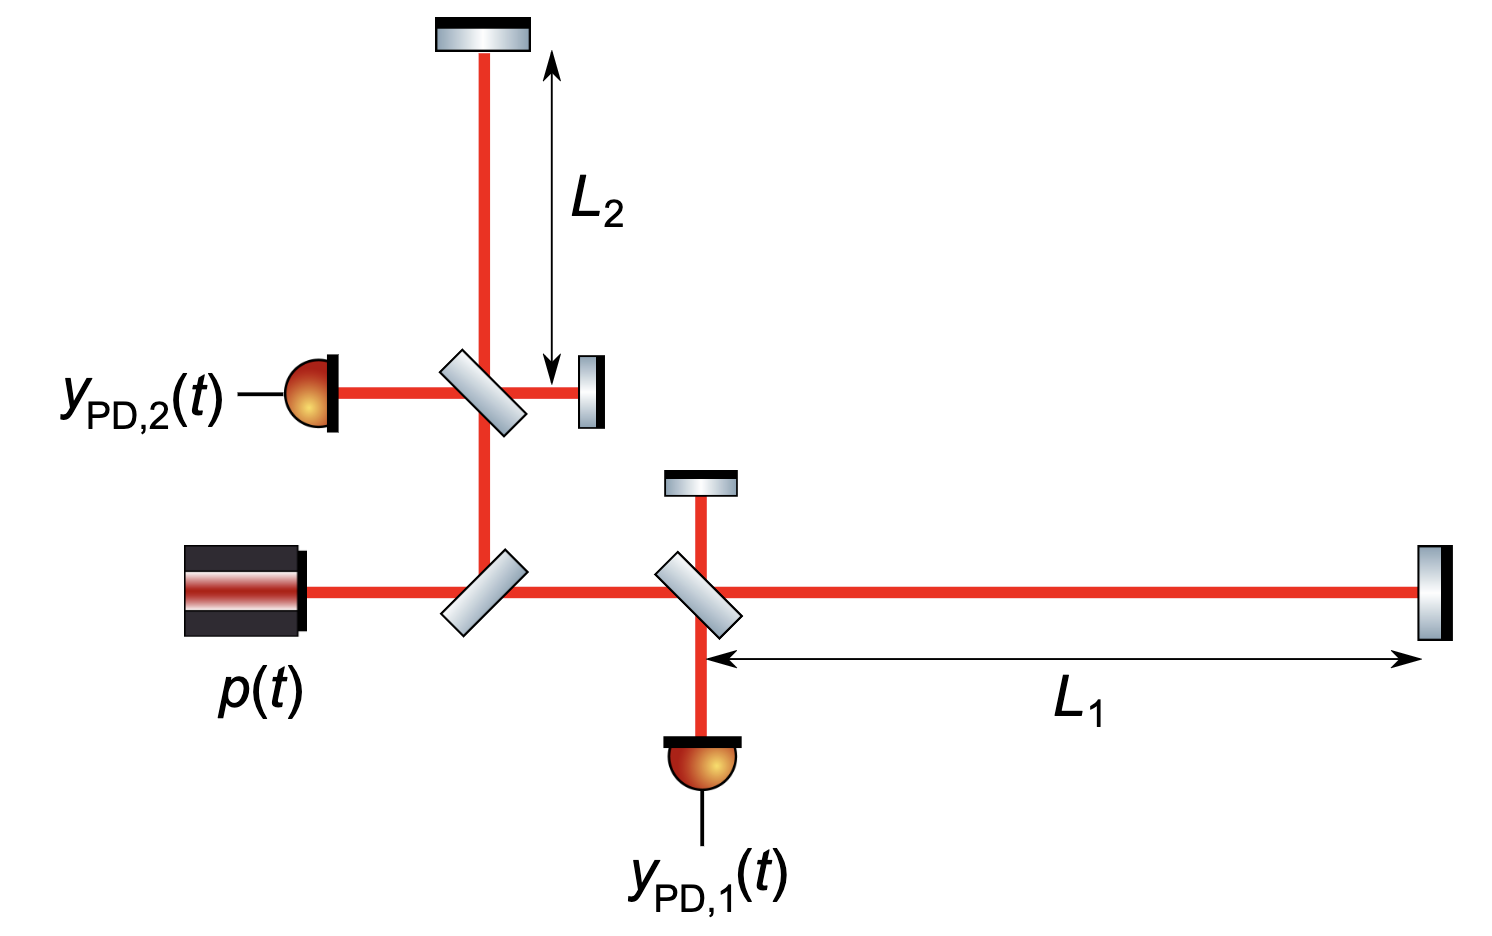

Fig. 12. Schematic of unequal-arm Michelson setup described above. Adapted from [10].

The time lengths $T_1, T_2$ indicate the round-trip light travel time down the long arms. We can't combine these two links alone to cancel out $p$;
$$y_{PD,1}(t) - y_{PD,2}(t) = H_1(t) - H_2(t) + p(t - T_1) - p(t - T_2) + N_1(t) - N_2(t).$$
However, we can consider the time-delayed quantities
\begin{align}
y_{PD,1}(t - T_2) &= H_1(t - T_2) + p(t - T_1 - T_2) - p(t - T_2) + N_1(t - T_2) \\
y_{PD,2}(t - T_1) &= H_2(t - T_1) + p(t - T_2 - T_1) - p(t - T_1) + N_2(t - T_1).
\end{align}
Here we notice
$$y_{PD,1}(t - T_2) - y_{PD,2}(t - T_1) = H_1(t - T_2) - H_2(t - T_1) + p(t - T_1) - p(t - T_2) + N_1(t - T_2) - N_2(t - T_1),$$
and we can subtract the undelayed strains such that we obtain a new quantity $x$:
\begin{align}
x(t) &\equiv (y_{PD,1}(t - T_2) - y_{PD,2}(t - T_1)) - (y_{PD,1}(t) - y_{PD,2}(t)) \\
&= H_1(t - T_2) - H_2(t - T_1) + H_2(t) - H_1(t) + \mathcal{N},
\end{align}
where the unavoidable, lower-magnitude noise sources are collected in the term $\mathcal{N}$. Thus, in principle, if we have unequal arms, we can cancel out the laser frequency noise _completely_, allowing us to get a quantity that only contains GW strains and stochastic noise.

### Michelson TDI Basis

The math above assumes fixed arm lengths such that $T_1$ and $T_2$ are time constants. The math and notation gets significantly more complicated when we consider a realistic LISA constellation, the time delays are not only time-varying but correlated across S/C. The most basic form of TDI assumes a non-rotating constellation with static arm lengths, known as TDI generation 1.0.

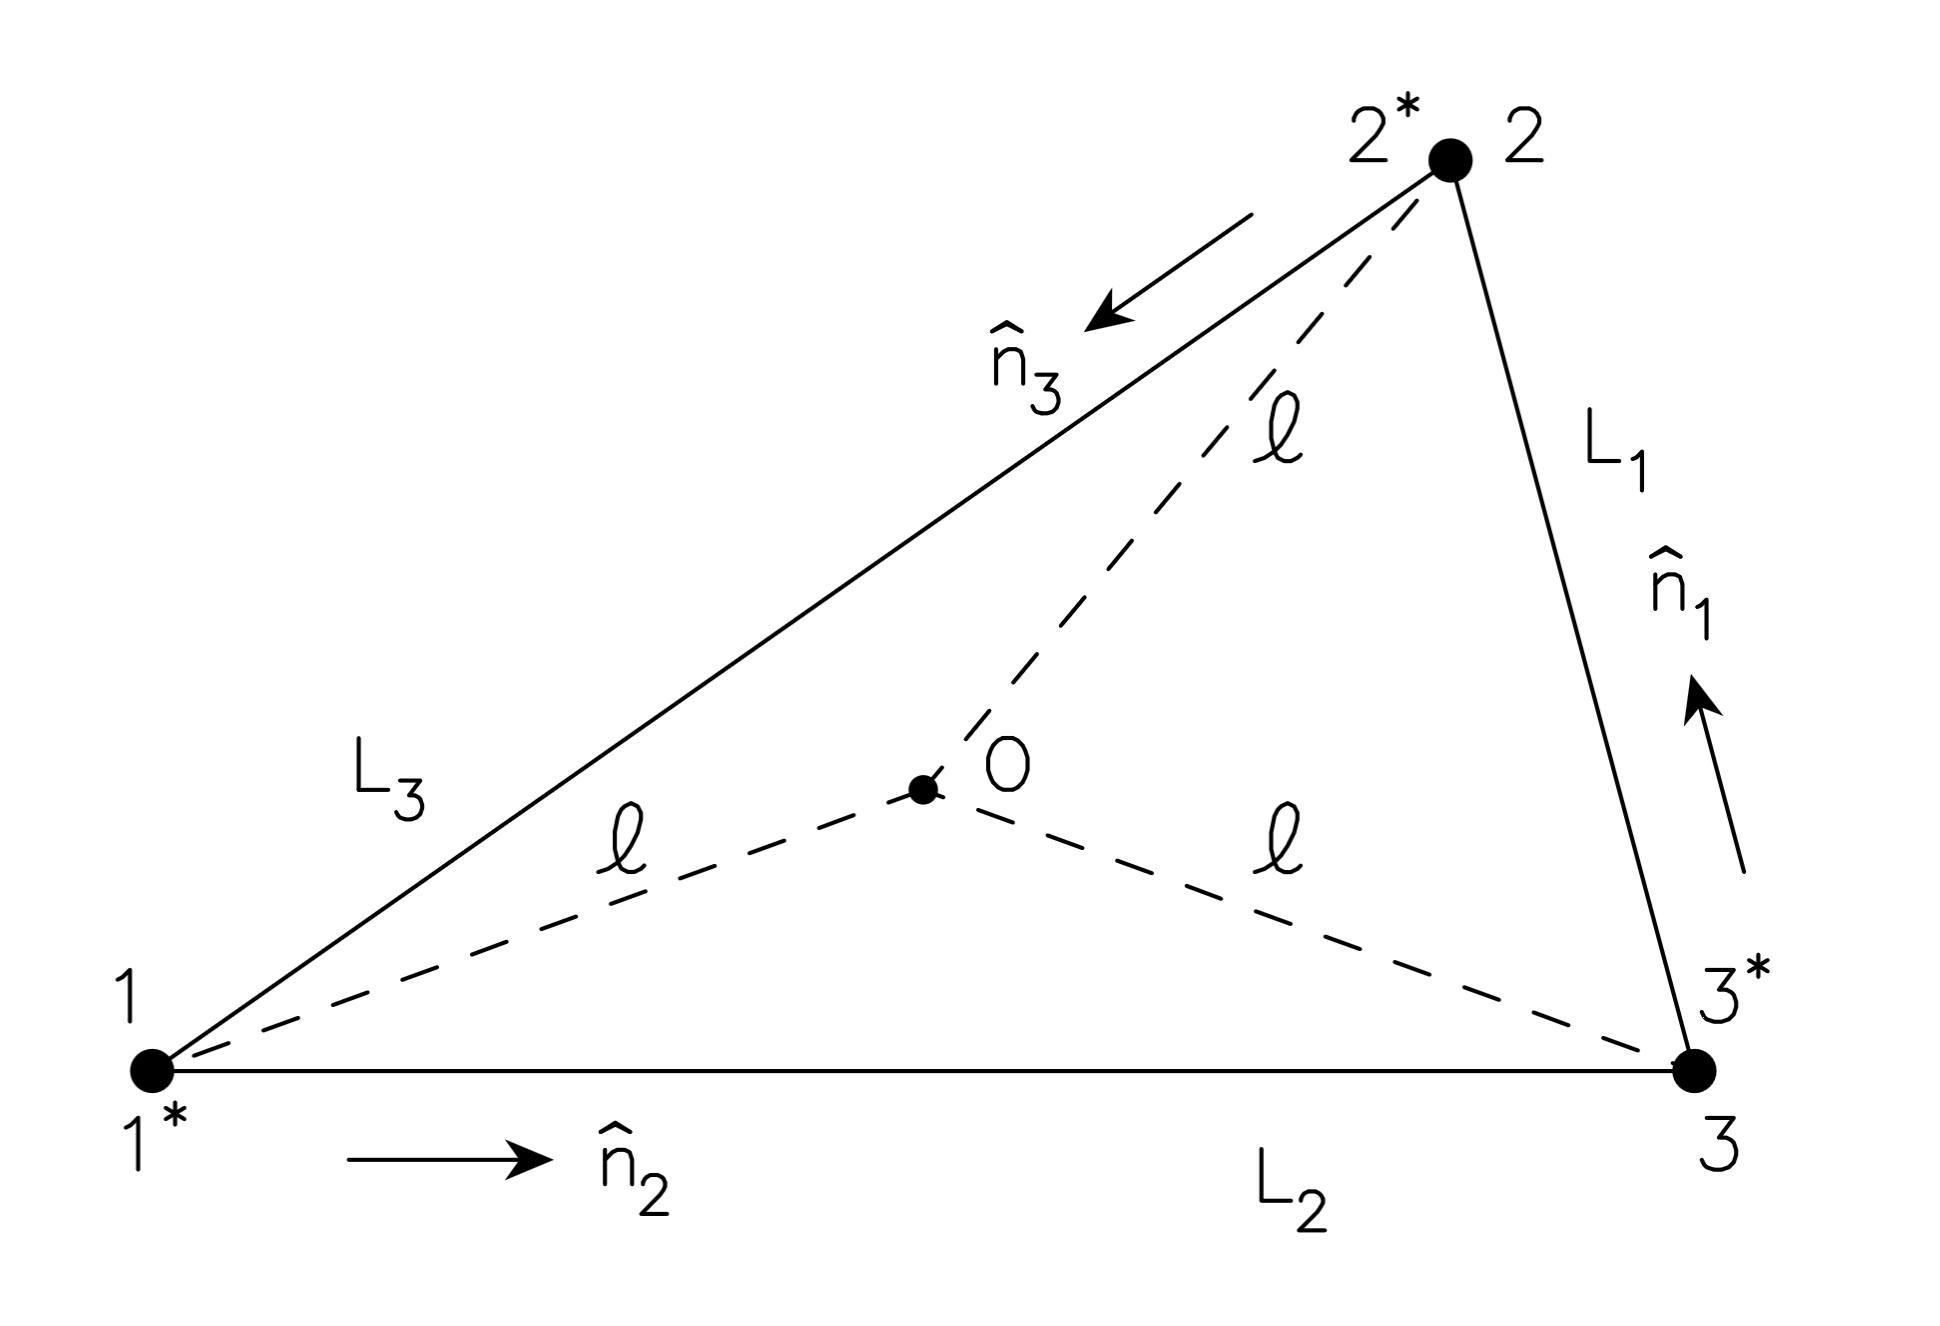

Fig. 13. Schematic of LISA constellation labels as used by the LDC. Adapted from [9].

The LDC manual uses a shorthand notation to compactify the time delays and labels for the links. The phase measurement measured by the laser propagating from S/C $s$ to S/C $r$ at an arbitrary time $t$ is denoted $y_{slr}(t)$. (The $l$ index denotes the direction of propagation. So, $y_{231}$ propagates along $\vec n_3$ from 2 to 1, whereas $y_{1-32}$ propagates along $-\vec n_3$ from 1 to 2.) Time delays are indicated with additional indices delineated with a comma:
$$y_{slr,i}(t) = y_{slr}(t - L_i(t))$$
$$y_{slr,i_1i_2...i_n}=y_{slr}(t - \sum_{i=1}^n L_i(t)).$$
With this notation, we can construct 1st generation _Michelson TDI observables_ $X, Y, Z$, where
$$X = y_{3-21} + y_{123,-2} + y_{231,2-2} + y_{1-32,32-2} - [y_{231} + y_{1-32,3} + y_{3-21,-33} + y_{123,-2-33}],$$
and $Y, Z$ are defined by cyclic permutations $1 \rightarrow 2 \rightarrow 3 \rightarrow 1$.

This is one of a several proposed TDI variables. This is the simplest and treats the LISA instrument as three Michelson interferometers. _Sagnac TDI observables_ treat the LISA instrument as a Sagnac interferometer and minimize the GW strain, allowing for measurements of the noise characteristics during operation (i.e. among continuous unresolvable signals). Other conbinations (_beacon_, _monitor_, and _relay_) for potential outages of one or multiple links have also been developed. The Michelson basis is most widely-used for GW data analysis.

### AET Basis

Combining links across different S/C in this way correlates the noise properties between links. Ideally, as in LVK, we want the noise in  observable data streams to be _uncorrelated_, i.e. we want the noise in one detector to be completely independent from all others. We can construct an uncorrelated basis by block diagonalizing the noise matrix
$$\Sigma = \begin{pmatrix}
S_{X} & S_{XY} & S_{XZ} \\
S_{YX} & S_{Y} & S_{YZ} \\
S_{ZX} & S_{ZY} & S_{Z} \\
\end{pmatrix}.$$
The resulting eigenvalues give the _AET Michelson basis_:
\begin{align}
A &= \frac{Z - X}{\sqrt{2}} \\
E &= \frac{X - 2Y + Z}{\sqrt{6}} \\
T &= \frac{X + Y + Z}{\sqrt{3}}.
\end{align}
This completely cancels out the cross-terms for equal armlengths. Future work is required to find a basis that generally cancels out the correlations between TDI observables.

### TDI Generations

As aforementioned, _1st generation TDI_ or _TDI 1.0_ refers to a TDI scheme that cancels out laser frequency noise perfectly for a non-rotating, static armlength LISA constellation. The TDI variables can be augmented by adding more time-delayed terms that account for additional constellation dynamics. In increasing order of complexity:
- _modified 1st generation TDI_ or _TDI 1.5_ still assumes rigid armlengths, but allows for the constellation to rotate. This means the armlength between two satellites is no longer exactly equal in both directions ($L_i \neq L_{-i}$). TDI still perfectly cancels out frequency noise in this case.
- _2nd generation TDI_ or _TDI 2.0_ assumes linear relative motion along the arms ("flexing") as well as rotation such that $$L_i(t) = L_i^0 + v_i t.$$ Hereafter, TDI no longer perfectly cancels out frequency noise; this approximation is good up to linear order.
- _3rd generation TDI_ or _TDI 3.0_ would assume a constant acceleration along the arms, corresponding to quadratic flexing $$L_i(t) = L_i^0 + v_i t + a_i t^2/2.$$ TDI now cancels out frequency noise up to quadratic order.
- Higher generations of TDI use higher orders of velocity derivatives to describe the flexing in the constellation. In general, TDI $N$.0 considers $(N-1)$th-order flexing effects along the arms.

## References

[1] P. Amaro-Seoane et al., “Laser Interferometer Space Antenna,” 2017. [Online]. Available:
https://arxiv.org/abs/1702.00786

[2] M. Armano et al., “Sub-femto-g free fall for space-based gravitational wave observatories:
LISA Pathfinder results,” Phys. Rev. Lett., vol. 116, p. 231101, Jun 2016. [Online]. Available:
https://link.aps.org/doi/10.1103/PhysRevLett.116.231101

[3] ——, “LISA Pathfinder,” 2019. [Online]. Available: https://arxiv.org/abs/1903.08924

[4] C. Cahillane and G. Mansell, “Review of the advanced LIGO gravitational wave observatories
leading to observing run four,” Galaxies, vol. 10, no. 1, 2022. [Online]. Available:
https://www.mdpi.com/2075-4434/10/1/36

[5] M. Colpi et al., “LISA definition study report,” 2024. [Online]. Available:
https://arxiv.org/abs/2402.07571

[6] F. B. Estabrook, M. Tinto, and J. W. Armstrong, “Time-delay analysis of LISA gravitational
wave data: Elimination of spacecraft motion effects,” Phys. Rev. D, vol. 62, p. 042002, Jul
2000. [Online]. Available: https://link.aps.org/doi/10.1103/PhysRevD.62.042002

[7] N. Houba, S. Delchambre, T. Ziegler, G. Hechenblaikner, and W. Fichter, “LISA point-
ahead angle control for optimal tilt-to-length noise estimation,” 2022. [Online]. Available:
https://arxiv.org/abs/2208.11033

[8] M. L. Katz, J.-B. Bayle, A. J. Chua, and M. Vallisneri, “Assessing the data-analysis impact
of LISA orbit approximations using a GPU-accelerated response model,” Physical Review D, vol.
106, no. 10, Nov. 2022. [Online]. Available: http://dx.doi.org/10.1103/PhysRevD.106.103001

[9] LISA Consortium’s LDC working group, “LISA Data Challenges,” 2019. Available: https://lisa-ldc.lal.in2p3.fr

[10] M. Otto, “Time-Delay Interferometry Simulations for the Laser Interferometer Space Antenna,”
Ph.D. dissertation, Leibniz U., Hannover, 2015.